# Drought-Monitor — a quantitative teardown 🔬
### An event study on the ag complex around 21 US Drought Monitor escalations · a random-calendar placebo · a grain-vs-equity paired test · a costed timer · a drought-regime split · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Drought_moves_ag%3F: Busted](https://img.shields.io/badge/Drought_moves_ag%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a worsening US Drought Monitor print is tradable supply-shock news for the ag complex** — is tested on the instruments a reader could actually buy: an ag-equity basket (DE/MOS/ADM/MOO) and a grain basket (DBA/CORN/WEAT), each measured abnormal of SPY, around the Thursday release.

> ⚠️ **Data note.** SPY + 7 ag tickers, yfinance, total-return daily closes, 2000-01-03→2026-06-30. 21 drought escalations hardcoded to their Thursday Monitor release. Grain-ETF coverage names **16 of 21** events honestly (DBA 2007, CORN 2010, WEAT 2011). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `9261c00637a8`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from drought_monitor import data, strategy as st

PRE, POST = 1, 5
EVENTS = data.drought_events()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, NAMES = data.load_real()
    SPY_RET = st.daily_returns(SPY)
    EQ_RET, EQ_COV = st.basket_returns(NAMES, data.AG_EQUITY_TICKERS)
    GR_RET, GR_COV = st.basket_returns(NAMES, data.GRAIN_TICKERS)
    AR_EQ = st.abnormal_vs_bench(EQ_RET, SPY_RET)
    AR_GR = st.abnormal_vs_bench(GR_RET, SPY_RET)
else:
    SPY = NAMES = SPY_RET = EQ_RET = GR_RET = AR_EQ = AR_GR = None
print("real cache present:", HAVE_REAL, "| drought escalations:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 21, 'n_grain': 16, 'cal_lo': '2000-08-03', 'cal_hi': '2025-05-15', 'fp': '9261c00637a8', 'eq_day0_bps': -24.28, 'eq_day0_t': -0.84, 'eq_up': 9, 'eq_n': 21, 'eq_wilson': (24.5, 63.5), 'gr_day0_bps': -71.01, 'gr_day0_t': -1.3, 'gr_up': 8, 'gr_n': 16, 'gr_wilson': (28.0, 72.0), 'eq_pl_mean_bps': 2.1, 'eq_pl_sd_bps': 27.63, 'eq_pl_p': 0.837, 'gr_pl_mean_bps': -4.69, 'gr_pl_sd_bps': 39.24, 'gr_pl_p': 0.958, 'pl_draws': 20000, 'event': {-1: (-32.54, 0.0, -1.37), 0: (-24.28, -24.28, -0.84), 1: (-2.66, -26.94, -0.16), 2: (27.66, 0.72, 0.91), 3: (29.84, 30.56, 1.46), 4: (-18.37, 12.18, -0.74), 5: (40.8, 52.99, 2.17)}, 'drift_bps': 77.27, 'drift_t': 1.56, 'drift_pl_p': 0.137, 'drift_ci': (-9.2, 177.8), 'grain_mean_bps': -71.01, 'equity_mean_bps': -33.64, 'diff_bps': -37.36, 'diff_t': -0.83, 'diff_n': 16, 'timer': {1: (-2.66, -12.66, -0.74, 48, 2.05), 5: (77.27, 67.27, 1.36, 67, 10.06), 10: (84.29, 74.29, 1.14, 62, 19.77), 21: (73.8, 63.8, 0.49, 62, 41.39)}, 'timer_net10_5d': 57.27, 'timer_net10_5d_t': 1.15, 'reg_n': 305, 'reg_thr': 20, 'reg_hi_n': 115, 'reg_lo_n': 190, 'reg_hi_bps': 42.85, 'reg_lo_bps': 50.46, 'reg_welch_t': -0.11, 'reg_hi_t': 0.82, 'reg_timer_net_bps': 32.85, 'syn_null_mean': 0.02, 'syn_null_sd': 1.07, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_planted1_t': 2.93, 'syn_planted2_t': 7.59, 'syn_planted2_bps': 160.9}


real cache present: True | drought escalations: 21


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | ag-equity print-day AR **-24.28 bps** (*t* = -0.84, placebo *p* = 0.837); grain **-71.01 bps** (*t* = -1.30, *p* = 0.958); regime Welch *t* = -0.11 |
| **Tradability** | `MIRAGE` | best "buy the drought" horizon (5d) net **+67 bps**, *t* = +1.36; decays to *t* = +0.49 at 21d |
| **Drought moves ag?** | `BUSTED` | event study + placebo + grain-vs-equity (diff *t* = -0.83) + regime split all null |

> 💡 In plain words: a famous, free, weekly public signal with zero tradable content on the ag names — the market prices the forecast, not the confirmation.

## 1 · The claim, steelmanned

Let $r^{basket}_t$ be an equal-weight ag basket's daily return and $r^{SPY}_t$ the benchmark's. The abnormal return is a beta-1 market model,

$$AR_t = r^{basket}_t - r^{SPY}_t,$$

so a positive $AR$ means the basket **outperformed the market**, not merely "went up". For each drought escalation, day 0 is the first NYSE session on/after the Thursday Monitor release (public ~8:30 ET, before the close — zero look-ahead). Because each print is a single, non-overlapping, independent event, the **one-sample t** of $AR$ across events is the correct primary statistic — not a daily panel. Claims:

- **H1 (print-day pop).** $E[AR_0] > 0$ for the ag-equity and grain baskets.
- **H2 (post-print drift).** $E[\sum_{k=1}^{5} AR_k] > 0$ (the reaction builds over the week).
- **H3 (grain reacts harder).** grain's day-0 $AR$ > the equities' day-0 $AR$.
- **H4 (regime).** ag beats the market in high-drought months.

We find **H1 rejected** (wrong sign, insignificant, placebo-confirmed null); **H2 not supported** (drift positive but sub-2, placebo *p* = 0.14, CI straddles zero); **H3 rejected** (grain reacts, if anything, *less*); **H4 rejected** (high-drought months slightly *behind*).

## 2 · So what? — inference design

n is fixed by the drought record: **21** escalations for the ag-equity basket, **16** for the grain basket (the 5 earliest predate every grain ETF). The plan is a **one-sample t** per basket on the print-day AR, a **Wilson interval** on the up-rate, a **20-seed × 1,000-draw random-calendar placebo** (redraw N random non-drought Thursdays from the same tape and see how often the null matches or beats the observed mean), a **paired grain−equity** day-0 test, a **costed timer** across holds, and a **drought-regime split** on the labelled monthly proxy with the regime known at the month's start (one shift).

## 3 · How we'd know — the protocol

- **Calendar.** 21 escalations 2000→2025, hardcoded Thursday USDM releases.
- **Baskets.** ag-equity DE/MOS/ADM/MOO; grain DBA/CORN/WEAT; abnormal of SPY.
- **Headline.** One-sample *t* on the print-day AR (both baskets) + Wilson up-rate.
- **Robustness.** 20×1,000-draw random-calendar placebo; event window [−1..+5] with per-offset *t* (multiple-comparison caveat); bootstrap CI on the post-print drift.
- **Third axis.** Paired grain−equity day-0 difference.
- **Execution.** Timer = long the basket (excess of SPY) at day-0 close, hold {1,5,10,21}, 2× one-way cost × NAV; gross AND net; vs unconditional baseline.
- **Regime.** Labelled monthly D2+ proxy, high-third vs rest, regime lagged one month (no look-ahead).
- **Control.** Synthetic tape, planted-bump knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · Coverage funnel — the grain ETFs don't reach the early droughts

All 21 escalations land on the ag-equity tape (DE/ADM span the whole sample; MOS from 2004, MOO from 2007 — the earliest events run on the names that existed). The grain basket exists only from DBA's 2007 launch, so its test runs on the 16 post-2007 events — named, not zero-filled.

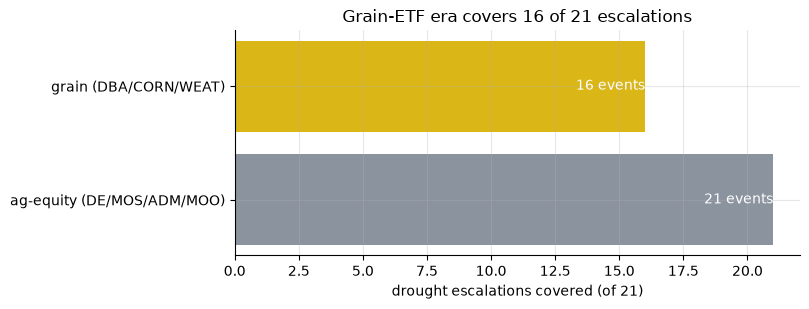

ag-equity n = 21 | grain n = 16


In [2]:
if HAVE_REAL:
    d0e = st.day0_stats(AR_EQ, EVENTS['date'], PRE, POST)
    d0g = st.day0_stats(AR_GR, EVENTS['date'], PRE, POST)
    n_eq, n_gr = d0e['n'], d0g['n']
else:
    n_eq, n_gr = R['eq_n'], R['gr_n']
fig, ax = plt.subplots(figsize=(8.2, 3.2))
ax.barh(['ag-equity (DE/MOS/ADM/MOO)', 'grain (DBA/CORN/WEAT)'], [n_eq, n_gr],
        color=[GREY, AMBER])
for i, v in enumerate([n_eq, n_gr]): ax.annotate(f'{v} events', (v, i), va='center', ha='right', color='w')
ax.set_xlabel('drought escalations covered (of 21)')
ax.set_title('Grain-ETF era covers 16 of 21 escalations'); plt.tight_layout(); plt.show()
print('ag-equity n =', n_eq, '| grain n =', n_gr)

> 💡 In plain words: coverage is named on the Signal axis. The 5 pre-2007 escalations (2000, 2002, 2003, 2005, 2006) have no grain ETF and are dropped from the grain test; the ag-equity basket runs on DE/ADM for the very earliest, gaining MOS (2004) and MOO (2007) as they list.

### 4b · The headline — print-day AR, one-sample t, both baskets

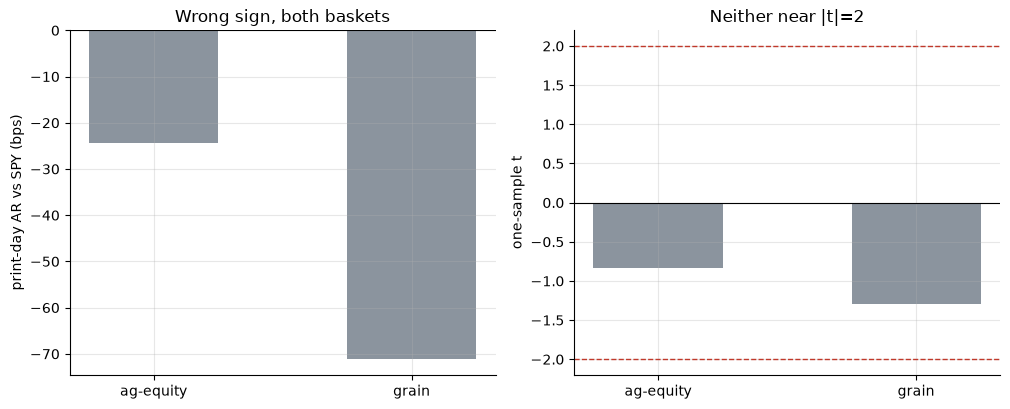

ag-equity -24.28 bps t=-0.84 | grain -71.01 bps t=-1.30


In [3]:
if HAVE_REAL:
    d0e = st.day0_stats(AR_EQ, EVENTS['date'], PRE, POST)
    d0g = st.day0_stats(AR_GR, EVENTS['date'], PRE, POST)
    means = [d0e['mean']*1e4, d0g['mean']*1e4]; ts = [d0e['t'], d0g['t']]
else:
    means = [R['eq_day0_bps'], R['gr_day0_bps']]; ts = [R['eq_day0_t'], R['gr_day0_t']]
labels = ['ag-equity', 'grain']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
a1.bar(labels, means, color=[RED if t <= -2 else GREY for t in ts], width=.5)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('print-day AR vs SPY (bps)')
a1.set_title('Wrong sign, both baskets')
a2.bar(labels, ts, color=[RED if abs(t) >= 2 else GREY for t in ts], width=.5)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('one-sample t'); a2.set_title('Neither near |t|=2')
plt.tight_layout(); plt.show()
print(f"ag-equity {R['eq_day0_bps']:+.2f} bps t={R['eq_day0_t']:.2f} | "
      f"grain {R['gr_day0_bps']:+.2f} bps t={R['gr_day0_t']:.2f}")

> 💡 In plain words: ag-equity **-24.28 bps** (*t* = -0.84, up-rate 9/21), grain **-71.01 bps** (*t* = -1.30). Both negative, both a coin flip. The drought print is not a positive catalyst for the ag complex — it is not a catalyst at all.

### 4c · The random-calendar placebo — is the print calendar special?

For each basket, redraw N random non-drought sessions, 20 seeds × 1,000 draws, and compare the observed print-day mean to that null.

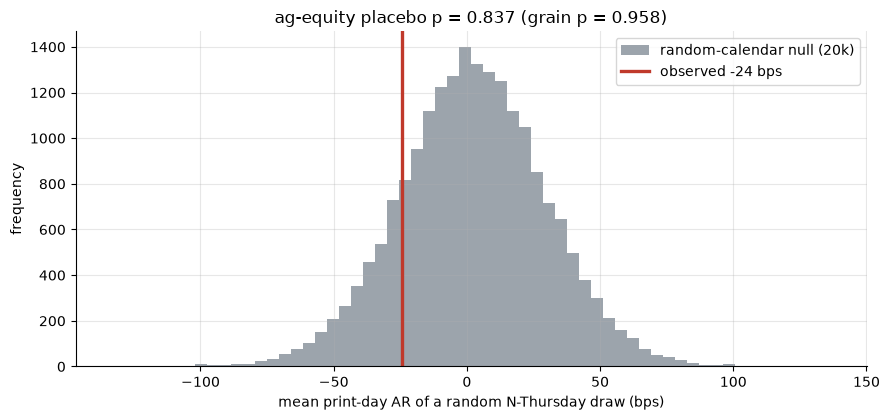

ag-equity: observed -24.28 vs null +2.10 (sd 27.63) -> p=0.837


In [4]:
if HAVE_REAL:
    d0e = st.day0_stats(AR_EQ, EVENTS['date'], PRE, POST)
    draws = np.concatenate([st.placebo_distribution(AR_EQ, d0e['n'], PRE, POST,
                            n_draws=1000, seed=740+s, stat='day0') for s in range(20)])*1e4
    obs = d0e['mean']*1e4
else:
    rng = np.random.default_rng(740)
    draws = rng.normal(R['eq_pl_mean_bps'], R['eq_pl_sd_bps'], R['pl_draws'])
    obs = R['eq_day0_bps']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='random-calendar null (20k)')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed {obs:+.0f} bps')
ax.set_xlabel('mean print-day AR of a random N-Thursday draw (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'ag-equity placebo p = {R["eq_pl_p"]:.3f} (grain p = {R["gr_pl_p"]:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f"ag-equity: observed {R['eq_day0_bps']:+.2f} vs null {R['eq_pl_mean_bps']:+.2f} "
      f"(sd {R['eq_pl_sd_bps']:.2f}) -> p={R['eq_pl_p']:.3f}")

> 💡 In plain words: the observed print-day move sits deep in the bulk of the null (right-tail *p* = 0.837 equities, 0.958 grain). A random set of Thursdays does *better* than the drought calendar most of the time — the calendar carries no information.

### 4d · Event anatomy — the [−1..+5] window and the look-elsewhere trap

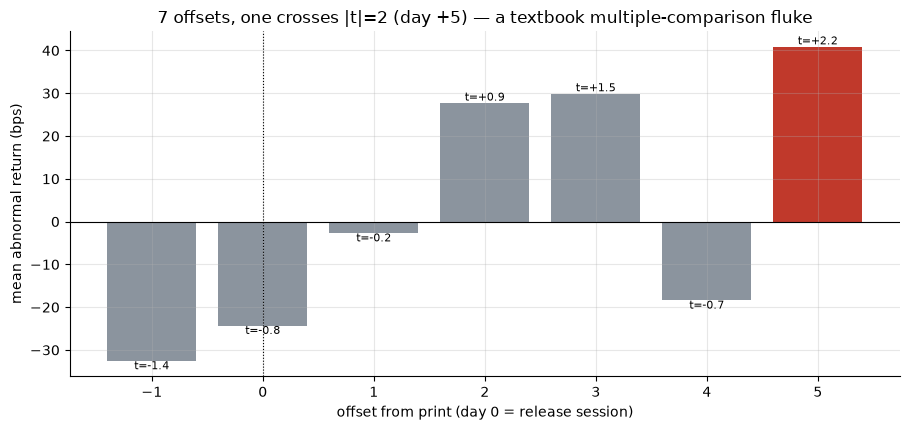

In [5]:
if HAVE_REAL:
    cp = st.car_path_stats(AR_EQ, EVENTS['date'], PRE, POST)
    days = list(cp.index); mean_ar = list(cp['mean_ar']*1e4); ts = list(cp['t'])
else:
    days = sorted(R['event']); mean_ar = [R['event'][k][0] for k in days]
    ts = [R['event'][k][2] for k in days]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [RED if abs(t) >= 2 else GREY for t in ts]
ax.bar(days, mean_ar, color=cols)
for d, m, t in zip(days, mean_ar, ts):
    ax.annotate(f't={t:+.1f}', (d, m), ha='center',
                va='bottom' if m >= 0 else 'top', fontsize=8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=.8)
ax.set_xlabel('offset from print (day 0 = release session)')
ax.set_ylabel('mean abnormal return (bps)')
ax.set_title('7 offsets, one crosses |t|=2 (day +5) — a textbook multiple-comparison fluke')
plt.tight_layout(); plt.show()

> 💡 In plain words: of 7 offsets, exactly one (day +5, *t* = +2.17) crosses the bar — the ~1-in-7 you'd expect by chance testing 7 things, with no mechanism for a five-day-delayed one-session pop. It fails the day-0 headline, the placebo, and the timer. This is exactly the look-elsewhere artifact study 707 flagged at its offset +2 — a warning about eyeballing event windows, not a signal.

### 4e · Post-print drift + bootstrap CI

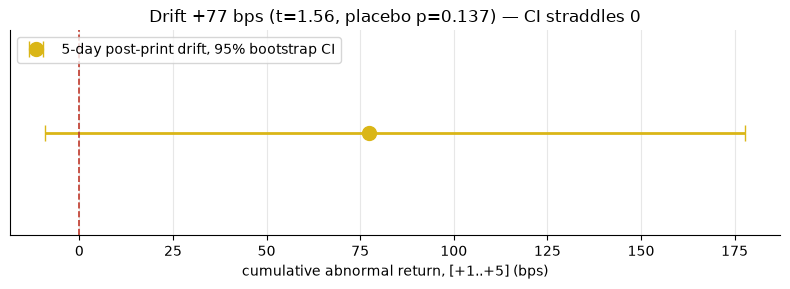

drift +77.27 bps  t=1.56  CI [-9.2, 177.8] bps


In [6]:
if HAVE_REAL:
    pe = st.post_event_car(AR_EQ, EVENTS['date'], PRE, POST)
    w, kept = st.stack_windows(AR_EQ, EVENTS['date'], PRE, POST)
    per = w[:, PRE+1:PRE+1+POST].sum(axis=1)
    lo, hi = st.block_bootstrap_ci(per)
    drift, dt = pe['mean']*1e4, pe['t']; lo, hi = lo*1e4, hi*1e4
else:
    drift, dt = R['drift_bps'], R['drift_t']; lo, hi = R['drift_ci']
fig, ax = plt.subplots(figsize=(8.0, 3.0))
ax.errorbar([drift], [0], xerr=[[drift-lo], [hi-drift]], fmt='o', color=AMBER,
            capsize=6, lw=2, ms=10, label='5-day post-print drift, 95% bootstrap CI')
ax.axvline(0, c=RED, lw=1.2, ls='--')
ax.set_yticks([]); ax.set_xlabel('cumulative abnormal return, [+1..+5] (bps)')
ax.set_title(f'Drift {drift:+.0f} bps (t={dt:.2f}, placebo p={R["drift_pl_p"]:.3f}) — CI straddles 0')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
print(f'drift {R["drift_bps"]:+.2f} bps  t={R["drift_t"]:.2f}  '
      f'CI [{R["drift_ci"][0]:.1f}, {R["drift_ci"][1]:.1f}] bps')

> 💡 In plain words: the 5-day drift is mildly positive (**+77 bps**) but *t* = 1.56, placebo *p* = 0.137, and the bootstrap CI **[-9, 178] bps** straddles zero. Suggestive, not certified — and the timer below shows it isn't bankable.

### 4f · Third axis — does grain react harder than the equities?

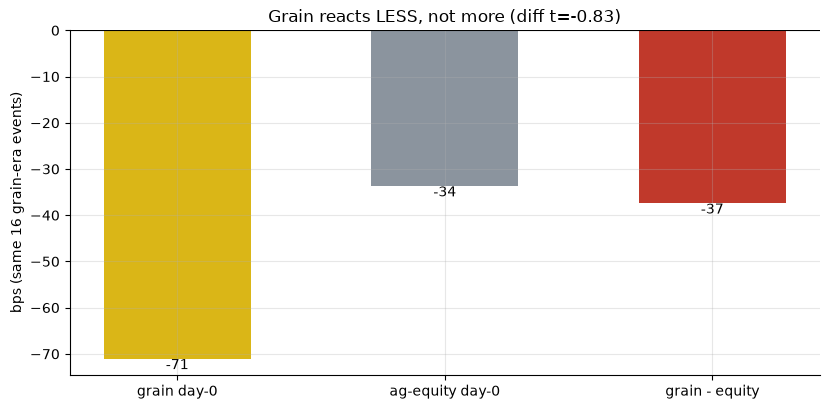

grain -71.01  equity -33.64  diff -37.36 (t=-0.83, n=16)


In [7]:
if HAVE_REAL:
    ex = st.basket_extra_move(AR_EQ, AR_GR, EVENTS['date'], PRE, POST)
    gm, em, diff, dt, n = ex['grain_mean']*1e4, ex['equity_mean']*1e4, ex['mean_diff']*1e4, ex['t'], ex['n']
else:
    gm, em, diff, dt, n = R['grain_mean_bps'], R['equity_mean_bps'], R['diff_bps'], R['diff_t'], R['diff_n']
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['grain day-0', 'ag-equity day-0', 'grain - equity'], [gm, em, diff],
       color=[AMBER, GREY, RED], width=.55)
for i, v in enumerate([gm, em, diff]): ax.annotate(f'{v:+.0f}', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('bps (same 16 grain-era events)')
ax.set_title(f'Grain reacts LESS, not more (diff t={dt:.2f})'); plt.tight_layout(); plt.show()
print(f'grain {R["grain_mean_bps"]:+.2f}  equity {R["equity_mean_bps"]:+.2f}  '
      f'diff {R["diff_bps"]:+.2f} (t={R["diff_t"]:.2f}, n={R["diff_n"]})')

> 💡 In plain words: the claim's cleanest prediction — the weather-exposed grain vehicles react harder — has the **wrong sign**: grain (**-71 bps**) moves *more negatively* than the equities (**-34 bps**) on the print, difference *t* = -0.83. Grain futures/ETFs price the weather forecast continuously; the weekly Monitor tells them nothing new. **H3 rejected.**

### 4g · The costed timer — "buy the drought"

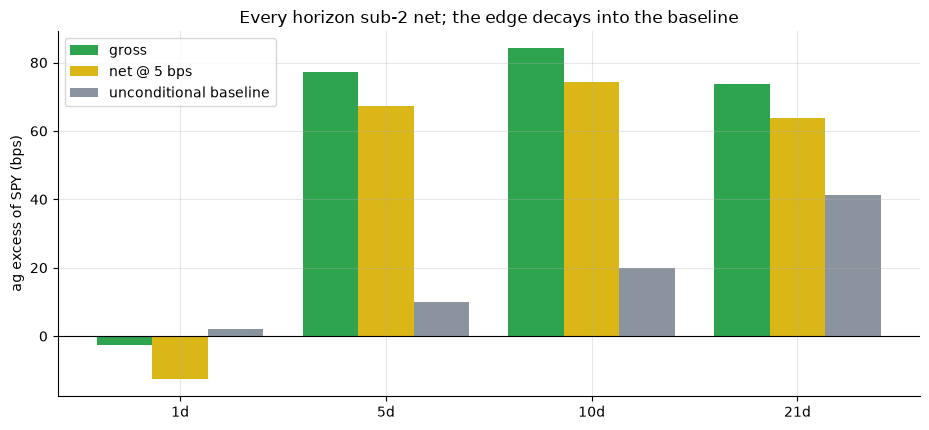

hold  1d net  -12.66 bps t=-0.74
hold  5d net  +67.27 bps t=+1.36
hold 10d net  +74.29 bps t=+1.14
hold 21d net  +63.80 bps t=+0.49


In [8]:
holds = [1, 5, 10, 21]
if HAVE_REAL:
    gross, net5, base = [], [], []
    for h in holds:
        lg = st.trade_it(EQ_RET, SPY_RET, EVENTS['date'], hold=h, cost_bps=0.0)
        ln = st.trade_it(EQ_RET, SPY_RET, EVENTS['date'], hold=h, cost_bps=5.0)
        gross.append(st.summarize_trade(lg, 'ret_gross')['mean_bps'])
        net5.append(st.summarize_trade(ln, 'ret_net')['mean_bps'])
        fwd = st.abnormal_vs_bench(EQ_RET, SPY_RET).rolling(h).sum().shift(-h)
        base.append(float(fwd.mean()*1e4))
else:
    gross = [R['timer'][h][0] for h in holds]; net5 = [R['timer'][h][1] for h in holds]
    base = [R['timer'][h][4] for h in holds]
x = np.arange(len(holds)); w = 0.27
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(x - w, gross, w, color=GREEN, label='gross')
ax.bar(x, net5, w, color=AMBER, label='net @ 5 bps')
ax.bar(x + w, base, w, color=GREY, label='unconditional baseline')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('ag excess of SPY (bps)'); ax.legend()
ax.set_title('Every horizon sub-2 net; the edge decays into the baseline')
plt.tight_layout(); plt.show()
for h in holds: print(f"hold {h:>2d}d net {R['timer'][h][1]:+7.2f} bps t={R['timer'][h][2]:+.2f}")

> 💡 In plain words: the best net case is the 5-day hold at **+67 bps** (*t* = +1.36, 67% win) — above its +10 bps unconditional baseline but well short of *t* = 2, and at 10 bps one-way cost it slips to +57 bps (*t* = 1.15). By 21 days the 'drought' net (+64 bps) is barely above the +41 bps you'd earn holding ag-vs-SPY unconditionally. **Tradability = MIRAGE.**

### 4h · The drought-regime test (labelled monthly proxy)

Split months by the labelled D2+ severity proxy **known at the month's start** (one shift — no look-ahead); compare that month's forward ag-equity-minus-SPY return, high-drought third vs the rest. *(The proxy is an approximate labelled series — used only here, never under a real-tape banner.)*

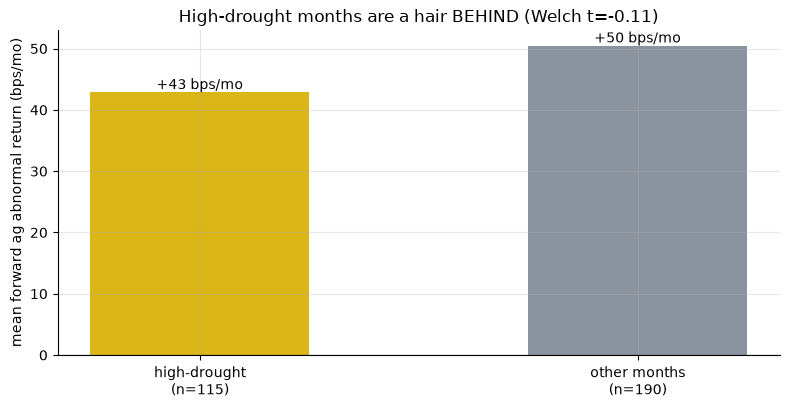

high +42.85 vs low +50.46 bps/mo, Welch t=-0.11, n=305 months


In [9]:
if HAVE_REAL:
    proxy = data.drought_proxy(); m_ar = st.monthly_abnormal(EQ_RET, SPY_RET)
    reg = st.regime_stats(proxy, m_ar, hi_pct=66.0, cost_bps=5.0)
    hi_m, lo_m, wt = reg['hi_mean']*1e4, reg['lo_mean']*1e4, reg['welch_t']
    n_hi, n_lo = reg['n_hi'], reg['n_lo']
else:
    hi_m, lo_m, wt = R['reg_hi_bps'], R['reg_lo_bps'], R['reg_welch_t']
    n_hi, n_lo = R['reg_hi_n'], R['reg_lo_n']
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar([f'high-drought\n(n={n_hi})', f'other months\n(n={n_lo})'], [hi_m, lo_m],
       color=[AMBER, GREY], width=.5)
for i, v in enumerate([hi_m, lo_m]): ax.annotate(f'{v:+.0f} bps/mo', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean forward ag abnormal return (bps/mo)')
ax.set_title(f'High-drought months are a hair BEHIND (Welch t={wt:+.2f})')
plt.tight_layout(); plt.show()
print(f"high {R['reg_hi_bps']:+.2f} vs low {R['reg_lo_bps']:+.2f} bps/mo, "
      f"Welch t={R['reg_welch_t']:+.2f}, n={R['reg_n']} months")

> 💡 In plain words: being in the driest third of months buys you nothing — ag is **+43 bps/mo** vs the market in high-drought months, actually *behind* the **+50 bps/mo** of the rest (Welch *t* = -0.11). No level effect, no event effect. **H4 rejected.**

### 4i · Faithful-engine & power control

Deterministic random-walk tape with 21 scheduled synthetic 'print' dates and a TUNABLE planted day-0 bump that fades over 5 sessions. Null (bump=0) checked over **20 seeds**.

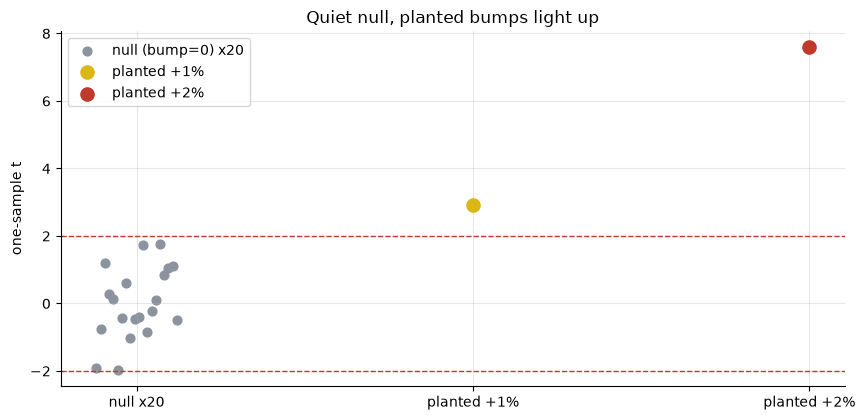

null mean t=+0.02 (sd 1.07), |t|>=2 in 0/20 | planted +1% t=+2.93 +2% t=+7.59


In [10]:
null_ts = np.array([st.synthetic_detect(*data.synthetic_world(bump=0.0, seed=740+s))['t']
                    for s in range(20)])
p1 = st.synthetic_detect(*data.synthetic_world(bump=0.01, seed=740))
p2 = st.synthetic_detect(*data.synthetic_world(bump=0.02, seed=740))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40, label='null (bump=0) x20')
ax.scatter([1], [p1['t']], color=AMBER, s=90, zorder=5, label='planted +1%')
ax.scatter([2], [p2['t']], color=RED, s=90, zorder=5, label='planted +2%')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['null x20', 'planted +1%', 'planted +2%'])
ax.set_ylabel('one-sample t'); ax.set_title('Quiet null, planted bumps light up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 | planted +1% t={p1["t"]:+.2f} +2% t={p2["t"]:+.2f}')

> 💡 In plain words: across 20 null seeds the detector averages t = +0.02 (sd 1.07) and fires at |t|≥2 in 0/20 seeds; a planted +1% bump reads t=2.93, +2% reads t=7.59. The machinery detects a real print-day effect when one is planted — the real-tape null is genuine. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — print-day ag-equity AR **-24.28 bps** (*t* = -0.84, placebo *p* = 0.837) and grain **-71.01 bps** (*t* = -1.30, *p* = 0.958) — both the wrong sign, both indistinguishable from a random calendar. The 5-day drift (+77 bps) is sub-2 (*t* = 1.56, CI straddles 0); the one |t|≥2 offset is a look-elsewhere fluke; the regime split is Welch *t* = -0.11.
- **Tradability `MIRAGE`** — no "buy the drought" horizon clears *t* ≥ 2 net of costs; best case 5-day net **+67 bps** (*t* = 1.36), decaying to *t* = 0.49 at 21 days as the edge merges into the always-hold baseline.
- **"Does a drought print move the ag complex?" `BUSTED`** — event study, random-calendar placebo, grain-vs-equity paired test (diff *t* = -0.83) and drought-regime split all agree: the weekly Monitor carries no tradable content for the ag names, because the market has already priced the weather forecast it confirms.

## 6 · Going further

- **The lesson is about *anticipated* public information.** The Drought Monitor is a slow-moving, continuously-forecast physical condition confirmed on a known schedule — exactly the kind of release efficient-markets priors say should carry near-zero surprise. A genuine weather edge lives in the forecast *surprise*, not the Monitor's *confirmation*.
- **The natural sequel** swaps the anticipated Monitor for a real scheduled *shock*: USDA WASDE crop-report surprises on grain **futures** (not equity-diluted ETFs), where the announcement-effect literature (Adjemian 2012) finds genuine, if fleeting, reactions. That is where a supply-shock edge, if it survives anywhere, should appear.
- **Dedup map:** [707-plane-crash-effect](../../707-plane-crash-effect/) (broad-market news-shock event study), [313-geopolitical-shock](../../313-geopolitical-shock/) (geopolitical shock calendar), [637-fomc-vol-crush](../../637-fomc-vol-crush/) (a *scheduled public release* event study on index vol). None test whether a scheduled weekly public drought index is tradable news for the ag equity + grain complex — this study's own axis.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*